<a href="https://colab.research.google.com/github/Sisterbobra/BCIS-466-Semester-Project-Maggie-Hanson/blob/main/Adult_Income_BCIS_466_SemesterProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & Imports
Installed the UCI respository using pip install and with the help of online lookups found the best sklearn modules to use to help with dataset processing raw data from the Adult dataset.

In [16]:
!pip install ucimlrepo -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Data
Goal: Get data from https://archive.ics.uci.edu/dataset/2/adult and import into Google Collab. Defining task and mission of dataset as said in the dataset abstract using dotdict to parse throught the UCI repository.

In [17]:
adult = fetch_ucirepo(id=2)
X_raw = adult.data.features
y_raw = adult.data.targets

print('Features shape:', X_raw.shape)
print('Target shape:  ', y_raw.shape)
print('\nMetadata snippet:')
print({k: adult.metadata[k] for k in ['name','abstract','area','task'] if k in adult.metadata})

df = X_raw.copy()
df['income'] = y_raw.iloc[:,0] if hasattr(y_raw, 'iloc') else y_raw

df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()
df.head()

Features shape: (48842, 14)
Target shape:   (48842, 1)

Metadata snippet:
{'name': 'Adult', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science'}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Exploratory Data Analysis (EDA)

Goal: Examine shape, data types, missing values (encoded as `?`), target balance, distributions of numeric features, and relationships with the target.

In [18]:
print('Shape:', df.shape)
print('\nDtypes:'); print(df.dtypes)
print('\nTarget distribution:'); print(df['income'].value_counts(normalize=True))
print('\nMissing values encoded as "?":')
for c in df.select_dtypes(include='object').columns:
    n = (df[c].astype(str).str.strip() == '?').sum()
    if n: print(f'  {c}: {n}')
df.describe()

Shape: (48842, 15)

Dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Target distribution:
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

Missing values encoded as "?":
  workclass: 1836
  occupation: 1843
  native-country: 583


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


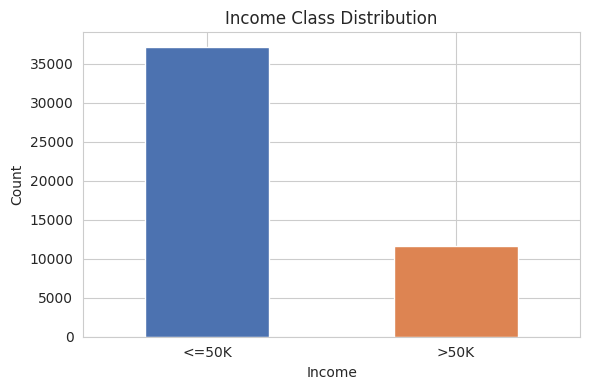

In [19]:
# Plot 1: income distributions
fig, ax = plt.subplots(figsize=(6,4))
df['income'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Income Class Distribution'); ax.set_xlabel('Income'); ax.set_ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

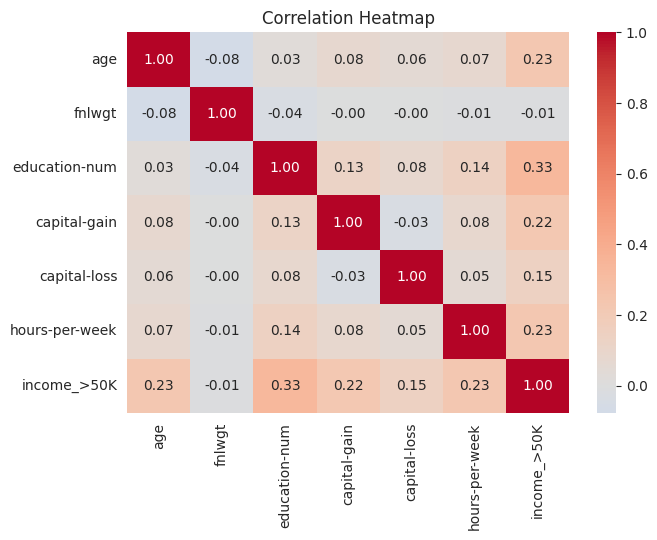

In [20]:
# Plot 2: correlation heatmap
numeric_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
corr_df = df[numeric_cols].copy()
corr_df['income_>50K'] = (df['income']=='>50K').astype(int)
plt.figure(figsize=(7,5.5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()

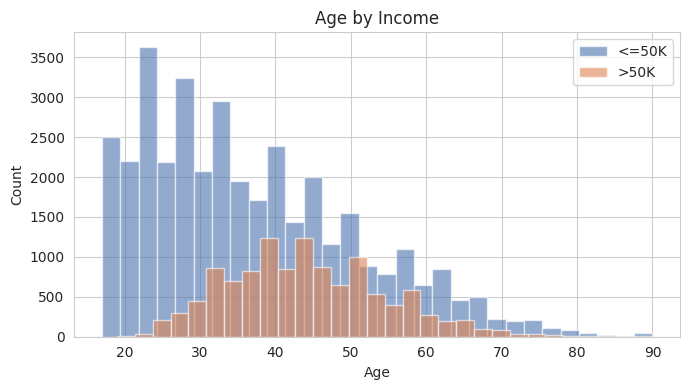

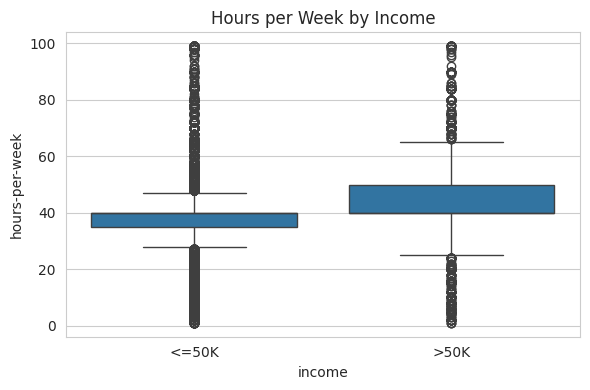

In [21]:
# Plot 3: age distribution by income
fig, ax = plt.subplots(figsize=(7,4))
for label, color in [('<=50K','#4C72B0'),('>50K','#DD8452')]:
    ax.hist(df.loc[df['income']==label,'age'], bins=30, alpha=0.6, label=label, color=color)
ax.set_title('Age by Income'); ax.set_xlabel('Age'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

# Plot 4: hours per week by income
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week by Income'); plt.tight_layout(); plt.show()

## 4. Preprocessing

- Replace `?` with NaN, then impute with the column mode for the three affected categoricies (Workclass, Occupation, and Native-Country).
- Standardize numeric features with `StandardScaler`.
- One-hot encode categorical features (workclass, education, marital-status, occupation, relationship, race, sex, native country) So that categorical data is easily represented to ensure useability for future machine learning.
- Encode income targets as 1 (`>50K`) / 0 (`<=50K`).

In [22]:
df_clean = df.replace('?', np.nan)
for c in ['workclass','occupation','native-country']:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

X = df_clean.drop(columns=['income'])
y = (df_clean['income']=='>50K').astype(int)

cat_features = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']
num_features = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])
print('Numeric:', num_features)
print('Categorical:', cat_features)

Numeric: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 5. Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train +ve rate: {y_train.mean():.3f}, Test +ve rate: {y_test.mean():.3f}')

Train: (39073, 14), Test: (9769, 14)
Train +ve rate: 0.239, Test +ve rate: 0.239


## 6. Train & Cross-Validate Multiple Models

I decided to use four different algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) to see how each model performs. I found that the best model to cross validate each algorithm at once is StratifiedKFold model with 5 splits.

In [24]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
trained = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]
    results.append({
        'Model': name,
        'CV Accuracy (mean)': cv_scores.mean(),
        'CV Accuracy (std)':  cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    })
    trained[name] = (pipe, y_pred, y_proba)

results_df = pd.DataFrame(results).round(4)
results_df

,Model,CV Accuracy (mean),CV Accuracy (std),Test Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8512,0.0021,0.8507,0.7314,0.5941,0.6557,0.9042
1,Decision Tree,0.8553,0.0017,0.8579,0.7984,0.5436,0.6468,0.9066
2,Random Forest,0.8615,0.0033,0.8662,0.8027,0.5847,0.6766,0.9178
3,Gradient Boosting,0.8719,0.0023,0.8773,0.7958,0.6553,0.7187,0.9292


## 7. Visualize Model Performance

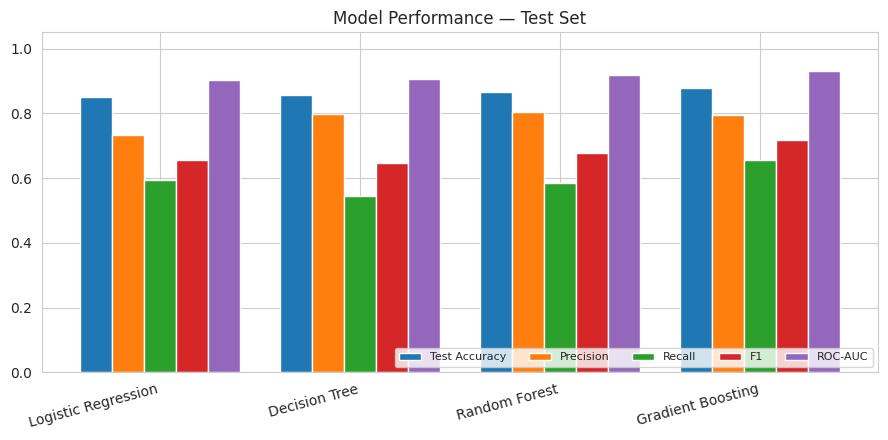

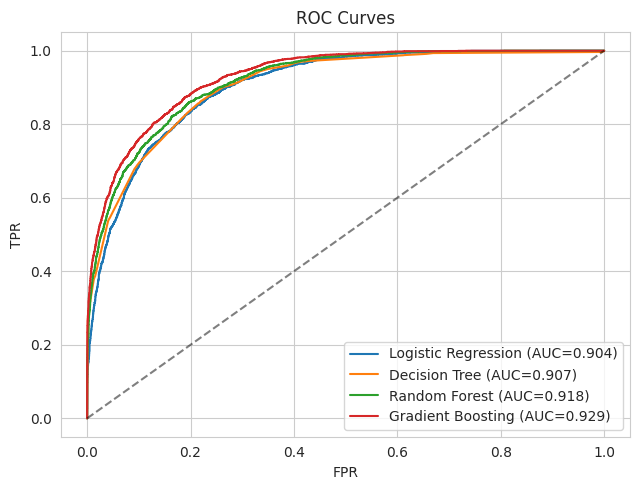

In [25]:
# Bar chart of test metrics
fig, ax = plt.subplots(figsize=(9,4.5))
metrics_to_plot = ['Test Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(results_df)); width = 0.16
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i*width, results_df[m], width, label=m)
ax.set_xticks(x + width*2); ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0,1.05); ax.set_title('Model Performance — Test Set'); ax.legend(loc='lower right', ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

# ROC curves
plt.figure(figsize=(6.5,5))
for name,(pipe,yp,ypr) in trained.items():
    fpr,tpr,_ = roc_curve(y_test, ypr)
    plt.plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,ypr):.3f})')
plt.plot([0,1],[0,1],'k--',alpha=0.5)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

Best model: Gradient Boosting


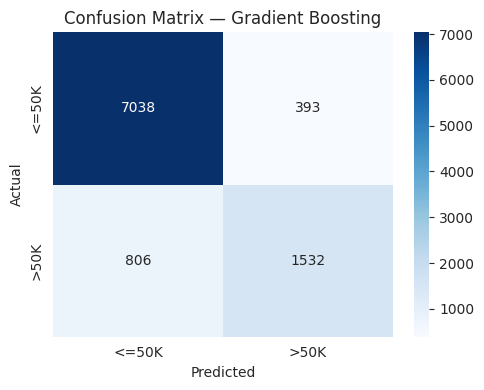

              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7431
        >50K       0.80      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [26]:
# Confusion matrix and classification report for the best model (by F1)
best_name = results_df.sort_values('F1', ascending=False).iloc[0]['Model']
print('Best model:', best_name)
pipe, y_pred, y_proba = trained[best_name]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, target_names=['<=50K','>50K']))

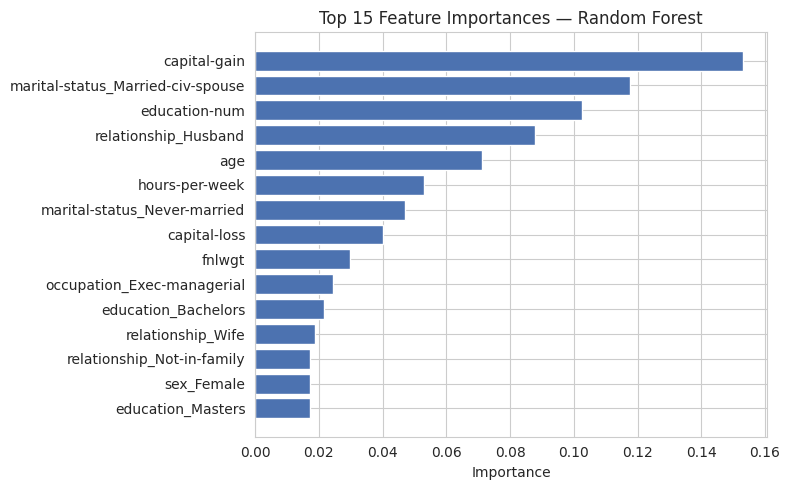

,feature,importance
3,capital-gain,0.153088
32,marital-status_Married-civ-spouse,0.117671
2,education-num,0.102631
51,relationship_Husband,0.087775
0,age,0.071210
5,hours-per-week,0.053033
34,marital-status_Never-married,0.046875
4,capital-loss,0.040261
1,fnlwgt,0.029752
40,occupation_Exec-managerial,0.024543


In [27]:
# Feature importance from Random Forest
rf_pipe = trained['Random Forest'][0]
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
all_features = list(num_features) + list(ohe.get_feature_names_out(cat_features))
fi = pd.DataFrame({'feature': all_features,
                   'importance': rf_pipe.named_steps['clf'].feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(15)
plt.figure(figsize=(8,5))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='#4C72B0')
plt.title('Top 15 Feature Importances — Random Forest'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()
fi

## 8. Hyperparameter Tuning

Brief grid search on the Gradient Boosting model to illustrate tuning.

In [28]:
gb_pipe = Pipeline([('prep', preprocessor),
                    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [3, 4, 5],
    'clf__learning_rate':[0.05, 0.1],
}
grid = GridSearchCV(gb_pipe, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV F1: ', round(grid.best_score_, 4))
y_pred_t = grid.predict(X_test)
y_prob_t = grid.predict_proba(X_test)[:,1]
print('Tuned test F1:     ', round(f1_score(y_test, y_pred_t), 4))
print('Tuned test ROC-AUC:', round(roc_auc_score(y_test, y_prob_t), 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Best CV F1:  0.7082
Tuned test F1:      0.7227
Tuned test ROC-AUC: 0.9297
